In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("olist.db")

query = """
SELECT 
    o.order_purchase_timestamp,
    oi.price,
    oi.product_id,
    p.product_category_name
FROM orders AS o
JOIN order_items AS oi
    ON o.order_id = oi.order_id
JOIN products AS p
    ON oi.product_id = p.product_id
WHERE o.order_status = 'delivered';
"""
df = pd.read_sql_query(sql=query, con=conn)

conn.close()

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["product_category_name"] = df["product_category_name"].fillna("unknown")

print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 4 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_purchase_timestamp  110197 non-null  datetime64[us]
 1   price                     110197 non-null  float64       
 2   product_id                110197 non-null  str           
 3   product_category_name     110197 non-null  str           
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 3.4 MB
None
  order_purchase_timestamp   price                        product_id  \
0      2017-10-02 10:56:33   29.99  87285b34884572647811a353c7ac498a   
1      2018-07-24 20:41:37  118.70  595fac2a385ac33a80bd5114aec74eb8   
2      2018-08-08 08:38:49  159.90  aa4383b373c6aca5d8797843e5594415   
3      2017-11-18 19:28:06   45.00  d0b61bfb1de832b15ba9d266ca96e5b0   
4      2018-02-13 21:18:39   19.90  65266b2da20d04dbe00c5c2d3bb7859e   

   product_categor

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_21728\2843291979.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


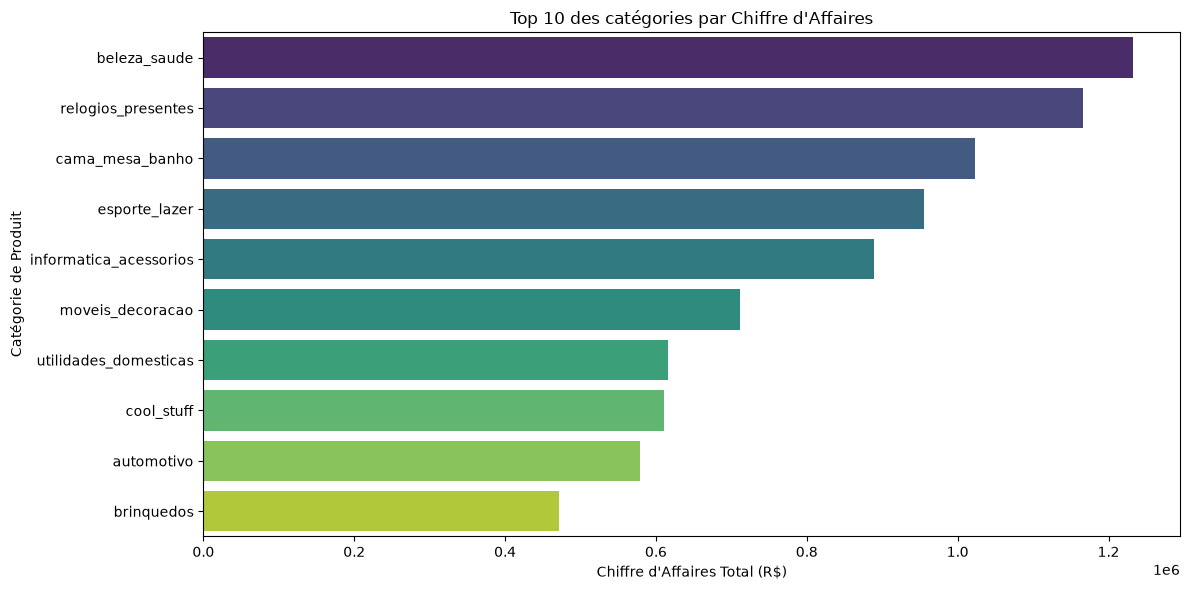

     product_category_name       price
11            beleza_saude  1233131.72
66      relogios_presentes  1166176.98
13         cama_mesa_banho  1023434.76
32           esporte_lazer   954852.55
44  informatica_acessorios   888724.61
54        moveis_decoracao   711927.69
73   utilidades_domesticas   615628.69
26              cool_stuff   610204.10
8               automotivo   578966.65
12              brinquedos   471286.48


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_top_categories = (
    df.groupby("product_category_name")["price"]
    .sum()
    .reset_index()
)

df_top_categories = df_top_categories.sort_values(
    by="price", ascending=False
)

top_10 = df_top_categories.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10,
    x="price",
    y="product_category_name",
    palette="viridis",
)

plt.title("Top 10 des catégories par Chiffre d'Affaires")
plt.xlabel("Chiffre d'Affaires Total (R$)")
plt.ylabel("Catégorie de Produit")
plt.tight_layout()
plt.show()

print(top_10)

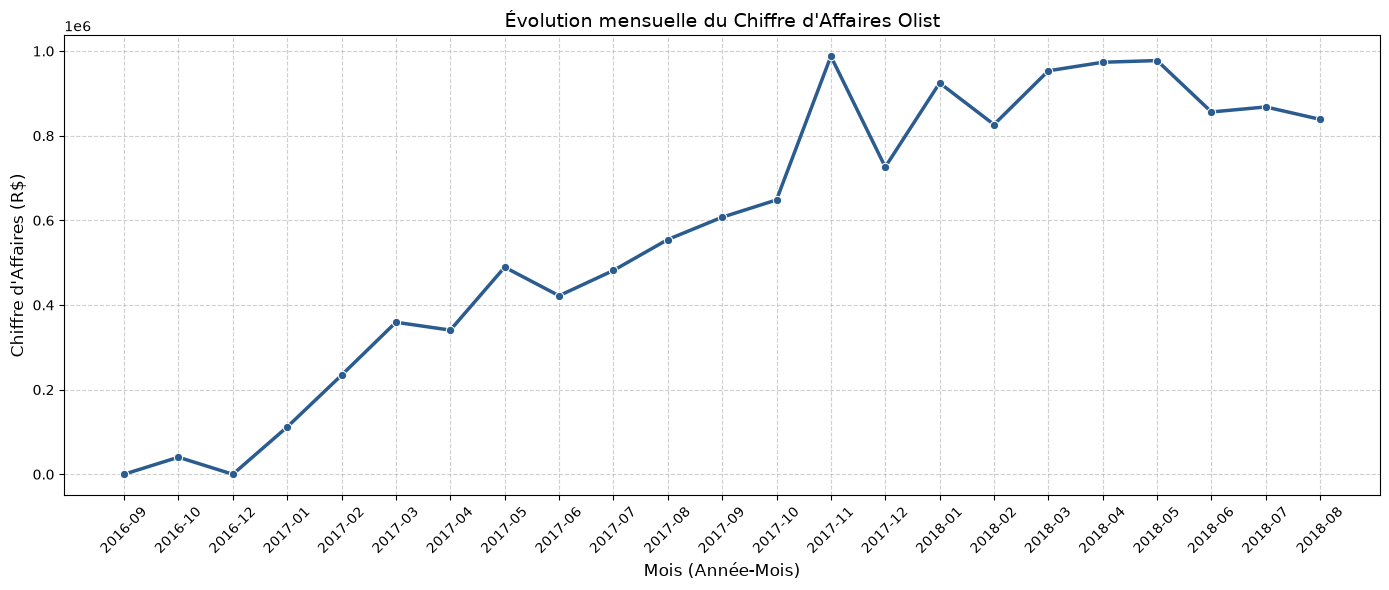

In [ ]:
df["year_month"] = df["order_purchase_timestamp"].dt.to_period("M")

df_monthly_sales = (
    df.groupby("year_month")["price"]
    .sum()
    .reset_index()
)

df_monthly_sales["year_month"] = df_monthly_sales["year_month"].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_monthly_sales,
    x="year_month",
    y="price",
    marker="o",
    color="#2b5c8f",
    linewidth=2.5,
)

plt.title("Évolution mensuelle du Chiffre d'Affaires Olist", fontsize=14)
plt.xlabel("Mois (Année-Mois)", fontsize=12)
plt.ylabel("Chiffre d'Affaires (R$)", fontsize=12)
plt.xticks(
    rotation=45
)  # Remplace ___ par un angle (ex: 45 ou 90) pour ne pas que les étiquettes se chevauchent !
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()